In [233]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [234]:
def load_json(path):
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except Exception:
                print(f"Warning: could not parse line {i} in {path}")
    return rows


def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def summarize_table(name, df):
    print(f"{name}: shape={df.shape}")
    if len(df) > 0:
        print(f"  columns={list(df.columns[:12])}" + (" ..." if len(df.columns) > 12 else ""))

In [235]:
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v4")
BUNDLES_DIR = OUTDIR / "bundles"

jobs_csv_final = OUTDIR / "results_jobs_final.csv"
alphas_csv_final = OUTDIR / "results_alphas_final.csv"
members_csv_final = OUTDIR / "results_members_final.csv"

jobs_csv_snapshot = OUTDIR / "results_jobs_snapshot.csv"
alphas_csv_snapshot = OUTDIR / "results_alphas_snapshot.csv"
members_csv_snapshot = OUTDIR / "results_members_snapshot.csv"

jobs_jsonl = OUTDIR / "results_jobs.jsonl"
alphas_jsonl = OUTDIR / "results_alphas.jsonl"
members_jsonl = OUTDIR / "results_members.jsonl"

meta_json = OUTDIR / "run_metadata.json"
summary_json = OUTDIR / "run_summary.json"

print("OUTDIR:", OUTDIR)
print("Exists:", OUTDIR.exists())
print("Bundles dir exists:", BUNDLES_DIR.exists())

OUTDIR: /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/multivariate_v4
Exists: True
Bundles dir exists: True


In [236]:
if jobs_csv_final.exists():
    jobs_df = pd.read_csv(jobs_csv_final)
elif jobs_csv_snapshot.exists():
    jobs_df = pd.read_csv(jobs_csv_snapshot)
else:
    jobs_df = pd.DataFrame(load_jsonl(jobs_jsonl))

if alphas_csv_final.exists():
    alphas_df = pd.read_csv(alphas_csv_final)
elif alphas_csv_snapshot.exists():
    alphas_df = pd.read_csv(alphas_csv_snapshot)
else:
    alphas_df = pd.DataFrame(load_jsonl(alphas_jsonl))

if members_csv_final.exists():
    members_df = pd.read_csv(members_csv_final)
elif members_csv_snapshot.exists():
    members_df = pd.read_csv(members_csv_snapshot)
else:
    members_df = pd.DataFrame(load_jsonl(members_jsonl))

meta = load_json(meta_json) if meta_json.exists() else {}
summary = load_json(summary_json) if summary_json.exists() else {}

bundle_npz_files = sorted(BUNDLES_DIR.glob("*.npz")) if BUNDLES_DIR.exists() else []
bundle_json_files = sorted(BUNDLES_DIR.glob("*.json")) if BUNDLES_DIR.exists() else []

summarize_table("jobs_df", jobs_df)
summarize_table("alphas_df", alphas_df)
summarize_table("members_df", members_df)

print("n bundle npz files:", len(bundle_npz_files))
print("n bundle json files:", len(bundle_json_files))

if meta:
    print("\nrun_metadata:")
    for k, v in meta.items():
        print(f"  {k}: {v}")

if summary:
    print("\nrun_summary:")
    for k, v in summary.items():
        print(f"  {k}: {v}")

jobs_df: shape=(140, 54)
  columns=['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax'] ...
alphas_df: shape=(560, 93)
  columns=['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax'] ...
members_df: shape=(16800, 42)
  columns=['member_id', 'ok', 'error', 'n_steps', 'path_length', 'net_displacement', 'mean_step', 'stagnant_frac', 'first_step_parent', 'end_parent', 'frac_parent1', 'frac_parent2'] ...
n bundle npz files: 572
n bundle json files: 572

run_metadata:
  seed: 11
  n_trials: 300
  n_workers: 120
  ensemble_size: 30
  flush_every: 10
  alpha_mix_grid: [0.2, 0.4, 0.6, 0.8]
  n_total_trials: 300
  n_completed_trials_found_at_start: 0
  n_pending_trials_at_start: 300
  updated_at: 2026-04-05T05:06:07.578911+00:00


In [237]:
if len(jobs_df) > 0:
    if "ok" in jobs_df.columns:
        print("Completed trial rows:", len(jobs_df))
        print("Successful trial rows:", int(jobs_df["ok"].sum()))
        print("Failed trial rows:", int((1 - jobs_df["ok"]).sum()))
    if "trial_id" in jobs_df.columns:
        print("Unique completed trial_ids:", jobs_df["trial_id"].nunique())

if len(alphas_df) > 0:
    print("\nAlpha rows per alpha_mix:")
    if "alpha_mix" in alphas_df.columns:
        print(alphas_df["alpha_mix"].value_counts(dropna=False).sort_index())

if len(members_df) > 0:
    print("\nMember rows:")
    if "trial_id" in members_df.columns:
        print("Unique trial_ids in members_df:", members_df["trial_id"].nunique())
    if "alpha_mix" in members_df.columns:
        print("Unique alpha_mix values in members_df:", sorted(pd.Series(members_df["alpha_mix"]).dropna().unique()))

Completed trial rows: 140
Successful trial rows: 140
Failed trial rows: 0
Unique completed trial_ids: 140

Alpha rows per alpha_mix:
0.2    140
0.4    140
0.6    140
0.8    140
Name: alpha_mix, dtype: int64

Member rows:
Unique trial_ids in members_df: 140
Unique alpha_mix values in members_df: [0.2, 0.4, 0.6, 0.8]


In [238]:
jobs_df.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'n_alpha', 'n_alpha_valid_physical',
       'frac_alpha_valid_physical', 'mean_mae_initial', 'mean_mae_end',
       'mean_mae_step', 'mean_mae_density', 'max_mae_initial', 'max_mae_end',
       'max_mae_step', 'max_mae_density', 'mean_ok_frac', 'min_ok_frac',
       'mean_mean_n_steps', 'min_q25_n_steps', 'mean_mean_net_displacement',
       'mean_mean_path_length', 'mean_mean_stagnant_frac',
       'mean_density_var2_frac', 'mean_step_var2_frac',
       'mean_initial_var2_frac', 'mean_end_var2_frac',
       'corr_alpha_vs_density_var1', 'corr_alpha_vs_step_var1',
       'corr_alpha_vs_end_var1', 'corr_alpha_vs_initial_var1',
       'corr_prescribed_vs_estimated_alpha_end',
      

In [239]:
alphas_df.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'alpha_mix', 'target_var1', 'target_var3',
       'initial_count_var1', 'initial_count_var2', 'initial_count_var3',
       'initial_frac_var1', 'initial_frac_var2', 'initial_frac_var3',
       'end_count_var1', 'end_count_var2', 'end_count_var3', 'end_frac_var1',
       'end_frac_var2', 'end_frac_var3', 'step_count_var1', 'step_count_var2',
       'step_count_var3', 'step_frac_var1', 'step_frac_var2', 'step_frac_var3',
       'density_integral_var1', 'density_integral_var2',
       'density_integral_var3', 'density_frac_var1', 'density_frac_var2',
       'density_frac_var3', 'member_mean_frac_var1', 'member_mean_frac_var2',
       'member_mean_frac_var3', 'member_std_frac_var1', '

In [240]:
members_df.keys()

Index(['member_id', 'ok', 'error', 'n_steps', 'path_length',
       'net_displacement', 'mean_step', 'stagnant_frac', 'first_step_parent',
       'end_parent', 'frac_parent1', 'frac_parent2', 'frac_parent3',
       'frac_nontrivial', 'any_nontrivial', 'ended_nontrivial',
       'unique_nontrivial_count', 'uses_parent1', 'uses_parent3',
       'uses_both_nontrivial', 'trial_id', 'alpha_mix', 'timewindow',
       'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax',
       'lambda_a', 'l1_ratio', 'dependence_threshold', 'max_iter',
       'fit_intercept', 'refit_ridge', 'ridge_alpha', 'bundle_npz',
       'bundle_json'],
      dtype='object')

# Analysis metrics

In [241]:
jobs_df.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'n_alpha', 'n_alpha_valid_physical',
       'frac_alpha_valid_physical', 'mean_mae_initial', 'mean_mae_end',
       'mean_mae_step', 'mean_mae_density', 'max_mae_initial', 'max_mae_end',
       'max_mae_step', 'max_mae_density', 'mean_ok_frac', 'min_ok_frac',
       'mean_mean_n_steps', 'min_q25_n_steps', 'mean_mean_net_displacement',
       'mean_mean_path_length', 'mean_mean_stagnant_frac',
       'mean_density_var2_frac', 'mean_step_var2_frac',
       'mean_initial_var2_frac', 'mean_end_var2_frac',
       'corr_alpha_vs_density_var1', 'corr_alpha_vs_step_var1',
       'corr_alpha_vs_end_var1', 'corr_alpha_vs_initial_var1',
       'corr_prescribed_vs_estimated_alpha_end',
      

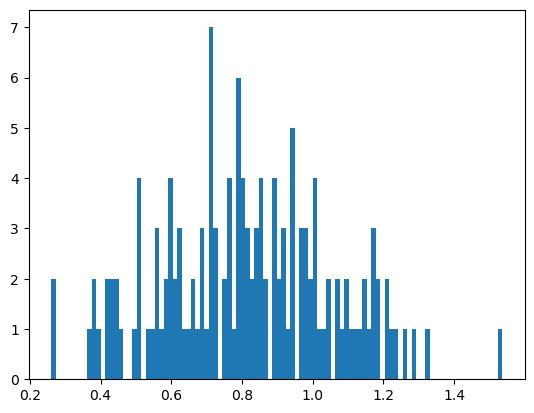

In [242]:
plt.hist(jobs_df.slope_prescribed_vs_estimated_alpha_density,bins=100)
plt.show()

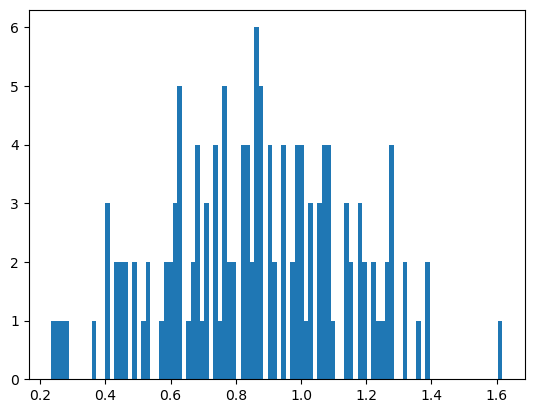

In [243]:
plt.hist(jobs_df.slope_prescribed_vs_estimated_alpha_end,bins=100)
plt.show()

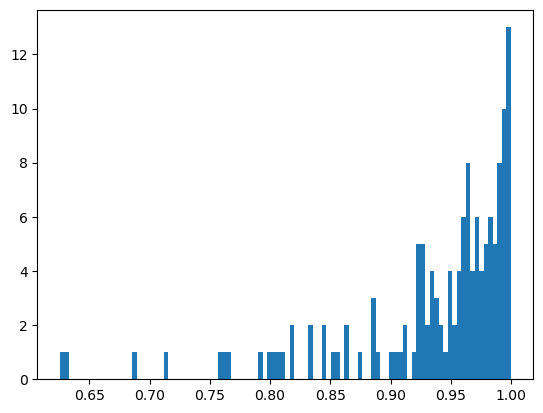

In [244]:
plt.hist(jobs_df.corr_alpha_vs_end_var1,bins=100)
plt.show()

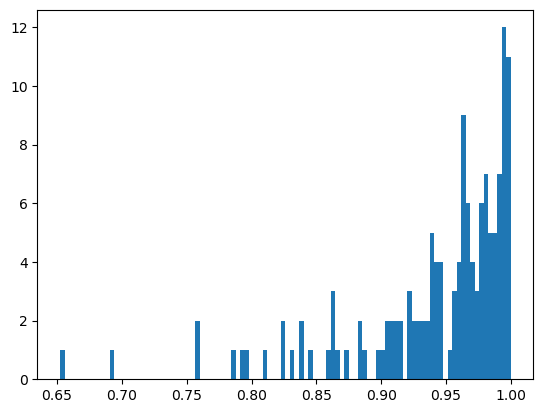

In [245]:
plt.hist(jobs_df.corr_alpha_vs_density_var1,bins=100)
plt.show()

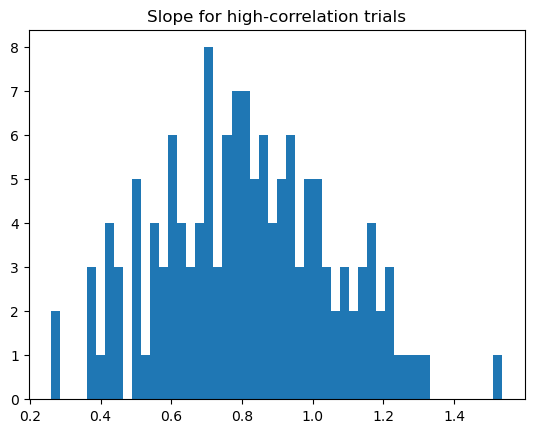

In [246]:
good = jobs_df[jobs_df["corr_prescribed_vs_estimated_alpha_density"] > 0.5]

plt.hist(good["slope_prescribed_vs_estimated_alpha_density"], bins=50)
plt.title("Slope for high-correlation trials")
plt.show()

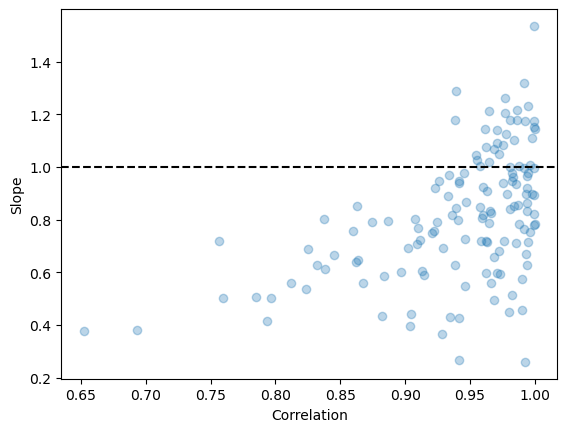

In [247]:
plt.scatter(
    jobs_df["corr_prescribed_vs_estimated_alpha_density"],
    jobs_df["slope_prescribed_vs_estimated_alpha_density"],
    alpha=0.3
)
plt.xlabel("Correlation")
plt.ylabel("Slope")
plt.axhline(1, color="k", linestyle="--")
plt.show()

# Relationship of hyperparams vs. performance

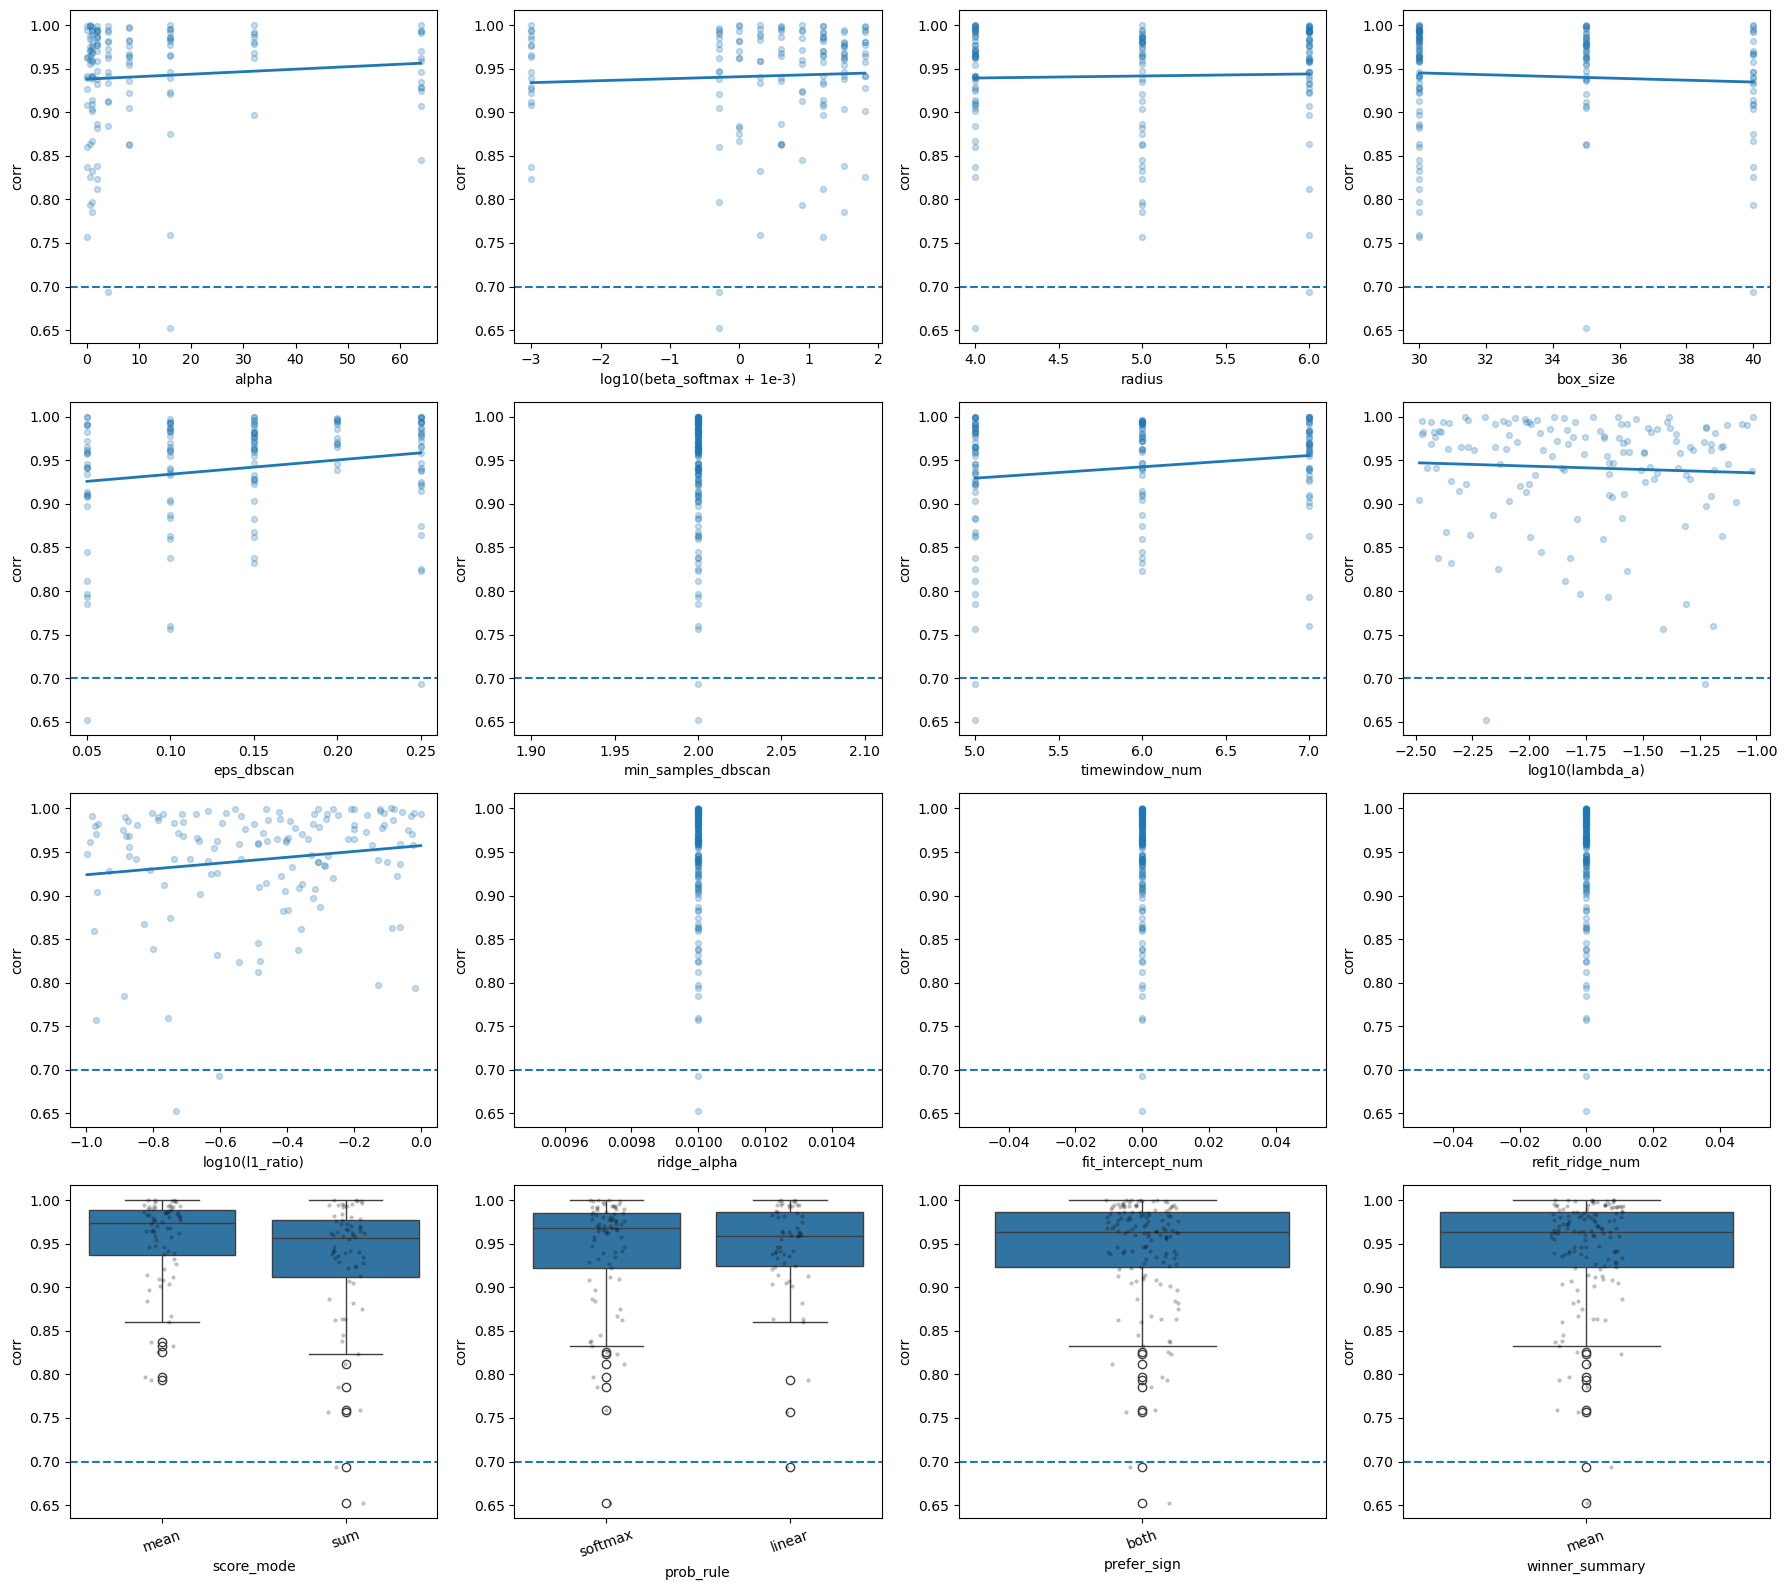

In [248]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = jobs_df.copy()

# existing
df_plot["timewindow_num"] = df_plot["timewindow"].str.replace("d", "", regex=False).astype(float)
df_plot["fit_intercept_num"] = df_plot["fit_intercept"].astype(int)
df_plot["refit_ridge_num"] = df_plot["refit_ridge"].astype(int)

# log transforms
df_plot["log10_lambda_a"] = np.log10(df_plot["lambda_a"])
df_plot["log10_l1_ratio"] = np.log10(df_plot["l1_ratio"])

# safe log for beta_softmax (handle zeros)
EPS = 1e-3
df_plot["log10_beta_softmax"] = np.log10(df_plot["beta_softmax"] + EPS)

df_plot["beta_regime"] = pd.cut(
    df_plot["beta_softmax"],
    bins=[-1, 0.1, 1.0, 8.0, 100],
    labels=["zero", "low", "medium", "high"]
)

target_col = "corr_prescribed_vs_estimated_alpha_density"

numeric_hp_cols = [
    "alpha",
    "log10_beta_softmax",   # ← updated
    "radius",
    "box_size",
    "eps_dbscan",
    "min_samples_dbscan",
    "timewindow_num",
    "log10_lambda_a",       # ← updated
    "log10_l1_ratio",       # ← updated
    "ridge_alpha",
    "fit_intercept_num",
    "refit_ridge_num",
]

categorical_hp_cols = [
    "score_mode",
    "prob_rule",
    "prefer_sign",
    "winner_summary",
    "beta_regime",
]

n_num = len(numeric_hp_cols)
n_cat = len(categorical_hp_cols)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# numeric: scatter + regression
for ax, col in zip(axes[:n_num], numeric_hp_cols):
    x = pd.to_numeric(df_plot[col], errors="coerce")
    y = pd.to_numeric(df_plot[target_col], errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)

    sns.regplot(
        x=x[mask],
        y=y[mask],
        ax=ax,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"linewidth": 2},
        ci=None,
    )
    label_map = {
        "log10_lambda_a": "log10(lambda_a)",
        "log10_l1_ratio": "log10(l1_ratio)",
        "log10_beta_softmax": "log10(beta_softmax + 1e-3)",
    }
    
    ax.set_xlabel(label_map.get(col, col))
    ax.set_ylabel("corr")
    ax.axhline(0.7, linestyle="--")

# categorical: boxplot + stripplot
start = n_num
for ax, col in zip(axes[start:start+n_cat], categorical_hp_cols):
    tmp = df_plot[[col, target_col]].dropna().copy()
    sns.boxplot(data=tmp, x=col, y=target_col, ax=ax)
    sns.stripplot(data=tmp, x=col, y=target_col, ax=ax, color="black", alpha=0.25, size=3)
    ax.set_xlabel(col)
    ax.set_ylabel("corr")
    ax.axhline(0.7, linestyle="--")
    ax.tick_params(axis="x", rotation=20)

# turn off unused axes
for ax in axes[start+n_cat:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

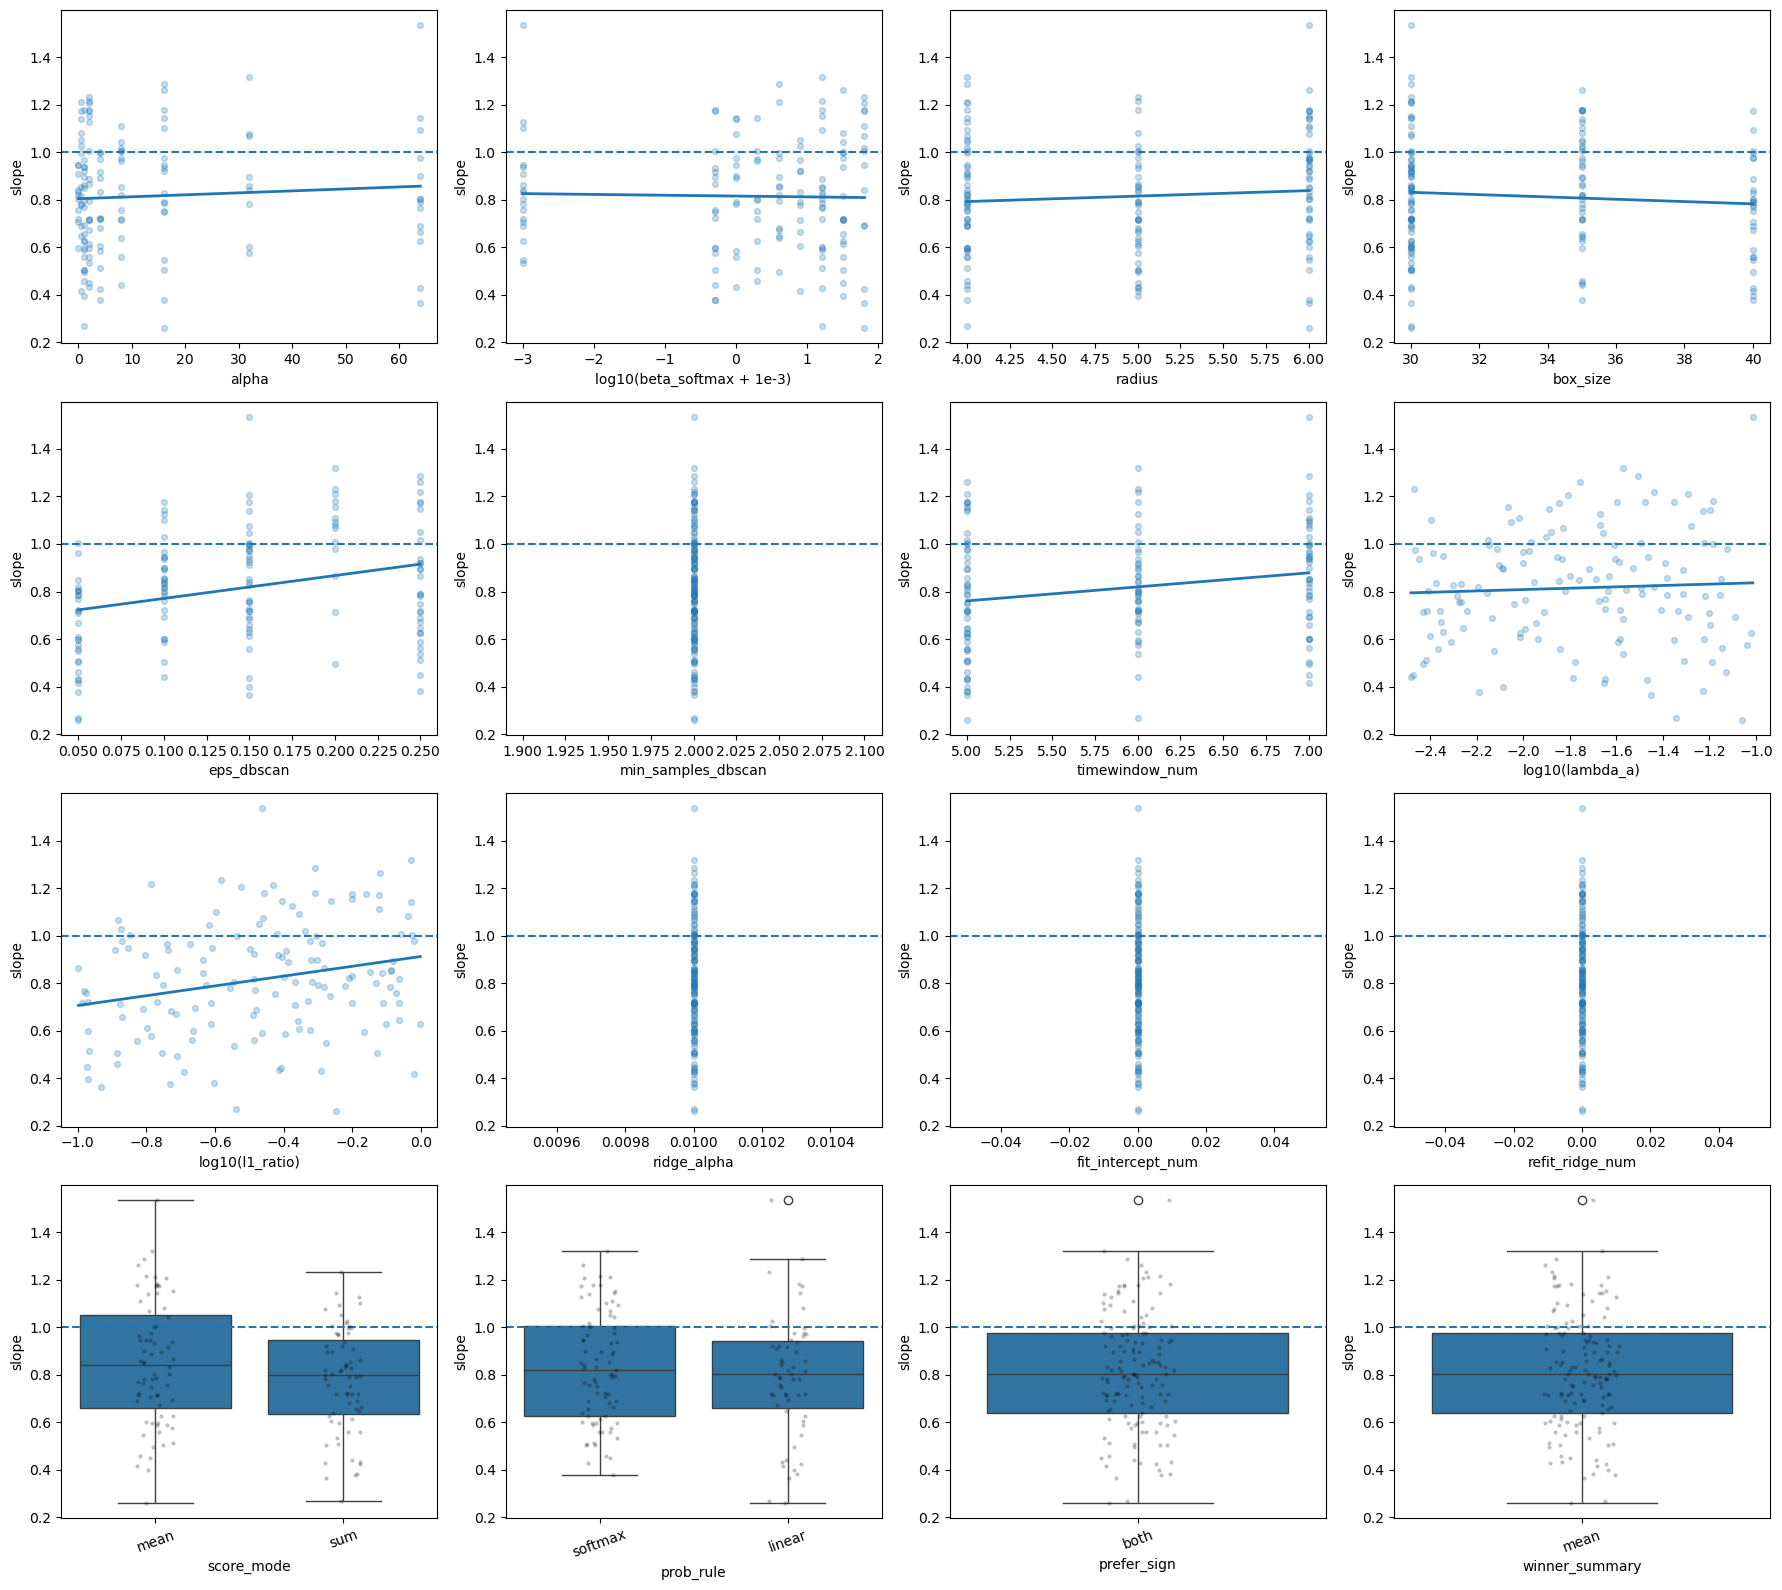

In [249]:
target_col = "slope_prescribed_vs_estimated_alpha_density"

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# numeric: scatter + regression
for ax, col in zip(axes[:n_num], numeric_hp_cols):
    x = pd.to_numeric(df_plot[col], errors="coerce")
    y = pd.to_numeric(df_plot[target_col], errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)

    sns.regplot(
        x=x[mask],
        y=y[mask],
        ax=ax,
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"linewidth": 2},
        ci=None,
    )
    label_map = {
        "log10_lambda_a": "log10(lambda_a)",
        "log10_l1_ratio": "log10(l1_ratio)",
        "log10_beta_softmax": "log10(beta_softmax + 1e-3)",
    }
    
    ax.set_xlabel(label_map.get(col, col))
    ax.set_ylabel("slope")
    ax.axhline(1.0, linestyle="--")

# categorical: boxplot + stripplot
start = n_num
for ax, col in zip(axes[start:start+n_cat], categorical_hp_cols):
    tmp = df_plot[[col, target_col]].dropna().copy()
    sns.boxplot(data=tmp, x=col, y=target_col, ax=ax)
    sns.stripplot(data=tmp, x=col, y=target_col, ax=ax, color="black", alpha=0.25, size=3)
    ax.set_xlabel(col)
    ax.set_ylabel("slope")
    ax.axhline(1.0, linestyle="--")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[start+n_cat:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [250]:
good.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'n_alpha', 'n_alpha_valid_physical',
       'frac_alpha_valid_physical', 'mean_mae_initial', 'mean_mae_end',
       'mean_mae_step', 'mean_mae_density', 'max_mae_initial', 'max_mae_end',
       'max_mae_step', 'max_mae_density', 'mean_ok_frac', 'min_ok_frac',
       'mean_mean_n_steps', 'min_q25_n_steps', 'mean_mean_net_displacement',
       'mean_mean_path_length', 'mean_mean_stagnant_frac',
       'mean_density_var2_frac', 'mean_step_var2_frac',
       'mean_initial_var2_frac', 'mean_end_var2_frac',
       'corr_alpha_vs_density_var1', 'corr_alpha_vs_step_var1',
       'corr_alpha_vs_end_var1', 'corr_alpha_vs_initial_var1',
       'corr_prescribed_vs_estimated_alpha_end',
      

Good runs: 138, Bad runs: 2


/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/56315602.py:50: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(b, ax=ax, label="bad", fill=True, alpha=0.35)
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/56315602.py:48: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(g, ax=ax, label="good", fill=True, alpha=0.35)
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/56315602.py:50: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(b, ax=ax, label="bad", fill=True, alpha=0.35)
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/56315602.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/glade/derecho/scra

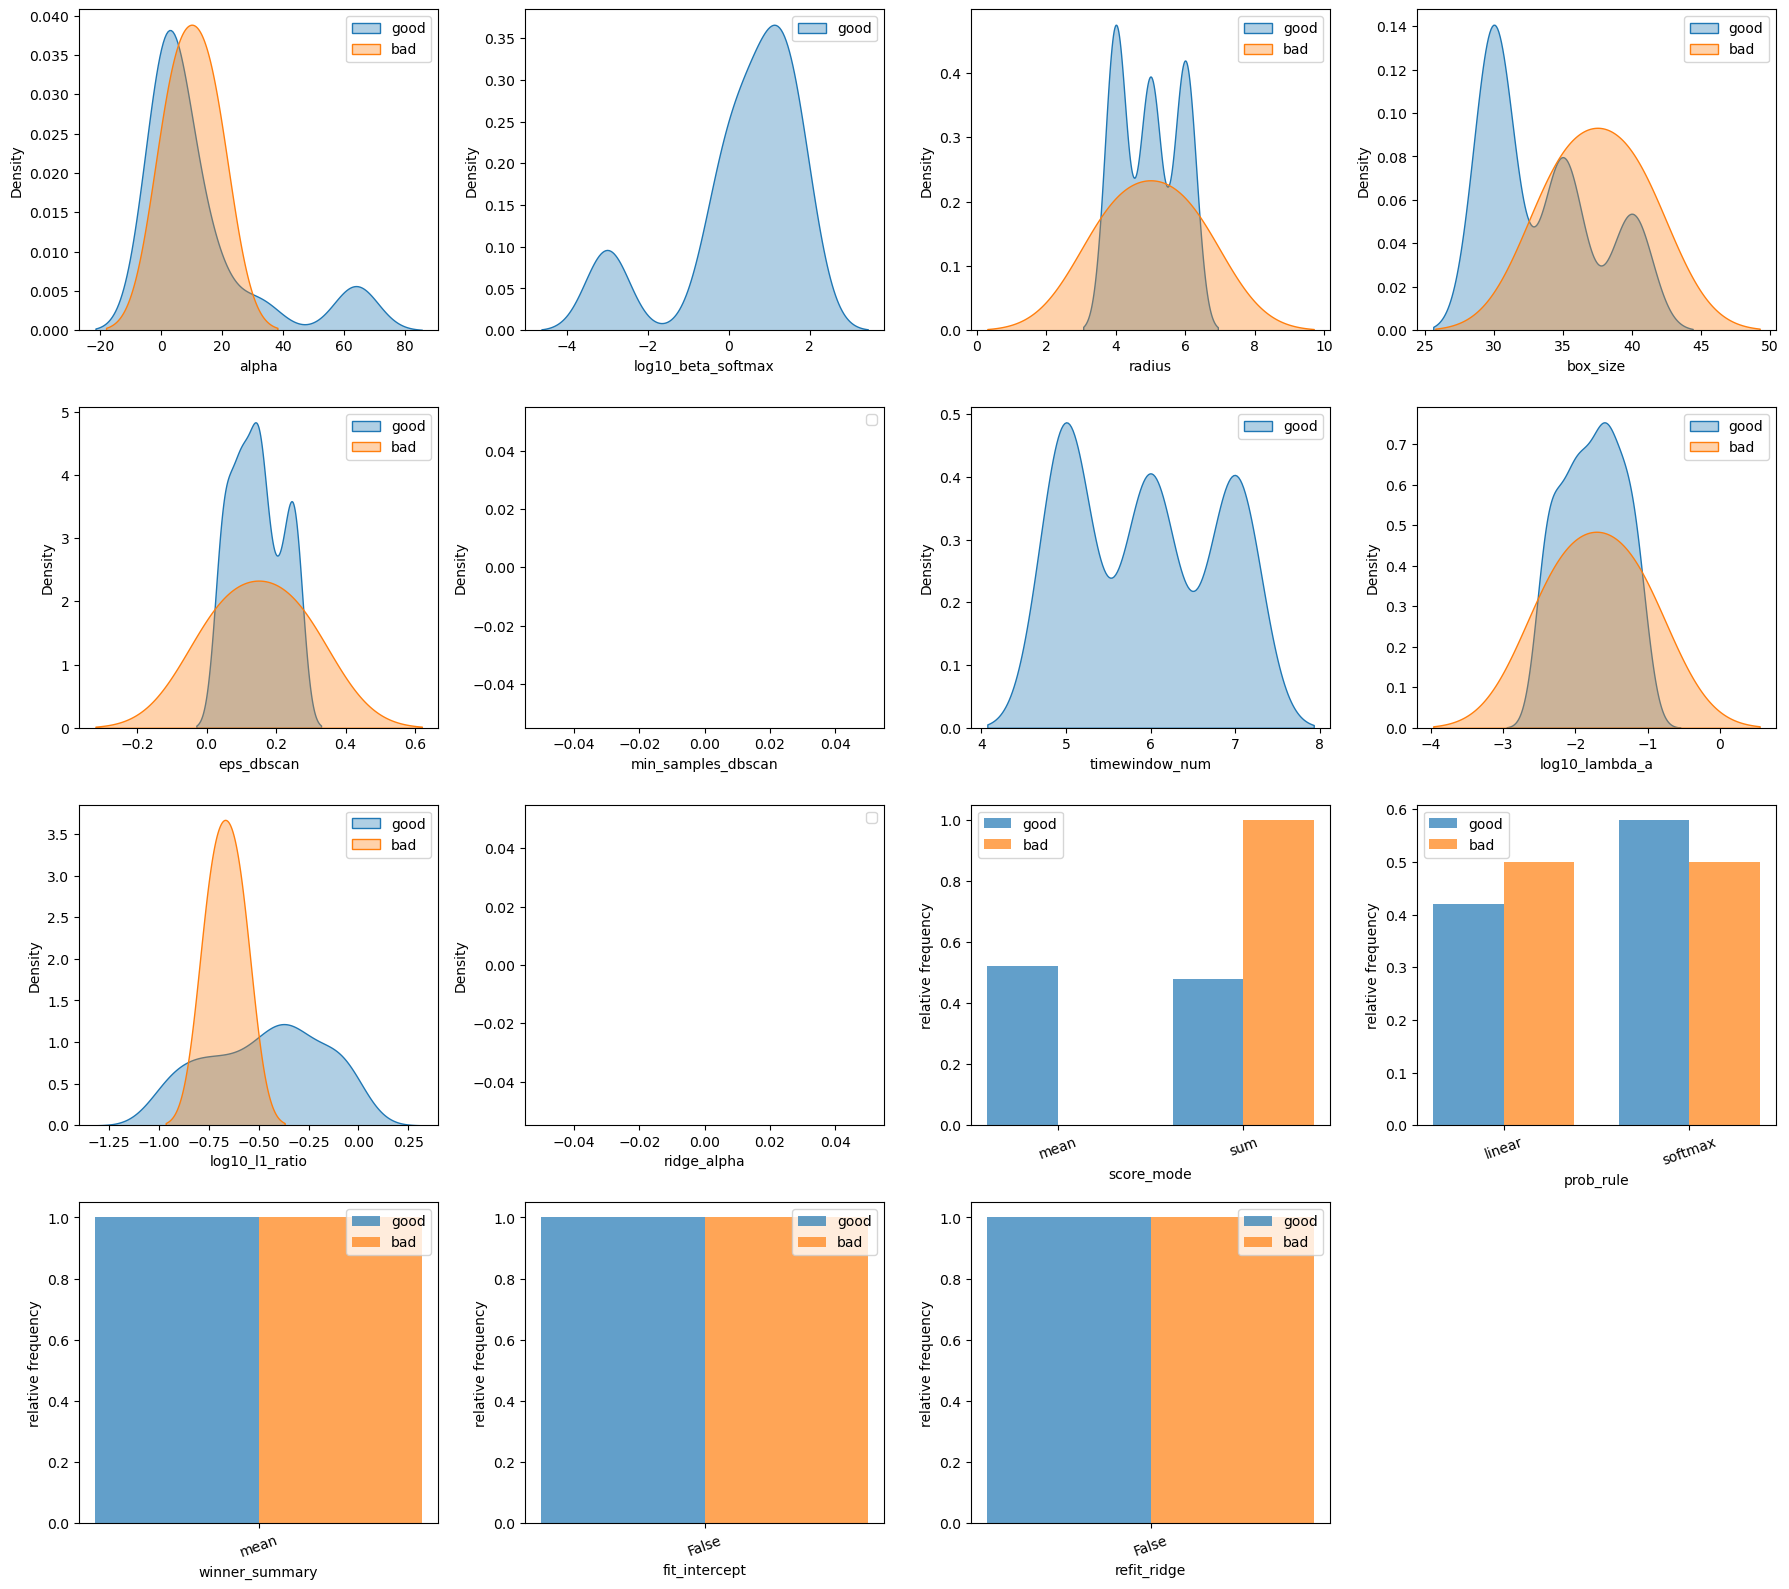

In [251]:
df_dist = jobs_df.copy()
df_dist["timewindow_num"] = df_dist["timewindow"].str.replace("d", "", regex=False).astype(float)
df_dist["fit_intercept_num"] = df_dist["fit_intercept"].astype(int)
df_dist["refit_ridge_num"] = df_dist["refit_ridge"].astype(int)

df_dist["log10_lambda_a"] = np.log10(df_dist["lambda_a"])
df_dist["log10_l1_ratio"] = np.log10(df_dist["l1_ratio"])
df_dist["log10_beta_softmax"] = np.log10(df_dist["beta_softmax"] + EPS)

good = df_dist[df_dist["corr_prescribed_vs_estimated_alpha_density"] > 0.7].copy()
bad  = df_dist[df_dist["corr_prescribed_vs_estimated_alpha_density"] <= 0.7].copy()

print(f"Good runs: {len(good)}, Bad runs: {len(bad)}")

dist_numeric_cols = [
    "alpha",
    "log10_beta_softmax",
    "radius",
    "box_size",
    "eps_dbscan",
    "min_samples_dbscan",
    "timewindow_num",
    "log10_lambda_a",
    "log10_l1_ratio",
    "ridge_alpha",
]

dist_categorical_cols = [
    "score_mode",
    "prob_rule",
    "winner_summary",
    "fit_intercept",
    "refit_ridge",
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# numeric distributions
for ax, col in zip(axes[:len(dist_numeric_cols)], dist_numeric_cols):
    g = pd.to_numeric(good[col], errors="coerce")
    b = pd.to_numeric(bad[col], errors="coerce")

    g = g[np.isfinite(g)]
    b = b[np.isfinite(b)]

    if len(g) > 1:
        sns.kdeplot(g, ax=ax, label="good", fill=True, alpha=0.35)
    if len(b) > 1:
        sns.kdeplot(b, ax=ax, label="bad", fill=True, alpha=0.35)

    ax.set_xlabel(col)
    ax.legend()

# categorical distributions
offset = len(dist_numeric_cols)
for ax, col in zip(axes[offset:offset+len(dist_categorical_cols)], dist_categorical_cols):
    g_counts = good[col].value_counts(normalize=True).sort_index()
    b_counts = bad[col].value_counts(normalize=True).sort_index()
    cats = sorted(set(g_counts.index).union(set(b_counts.index)))

    x = np.arange(len(cats))
    width = 0.38

    ax.bar(x - width/2, [g_counts.get(c, 0.0) for c in cats], width=width, label="good", alpha=0.7)
    ax.bar(x + width/2, [b_counts.get(c, 0.0) for c in cats], width=width, label="bad", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20)
    ax.set_xlabel(col)
    ax.set_ylabel("relative frequency")
    ax.legend()

for ax in axes[offset+len(dist_categorical_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Plot a specific trial with a specific alpha

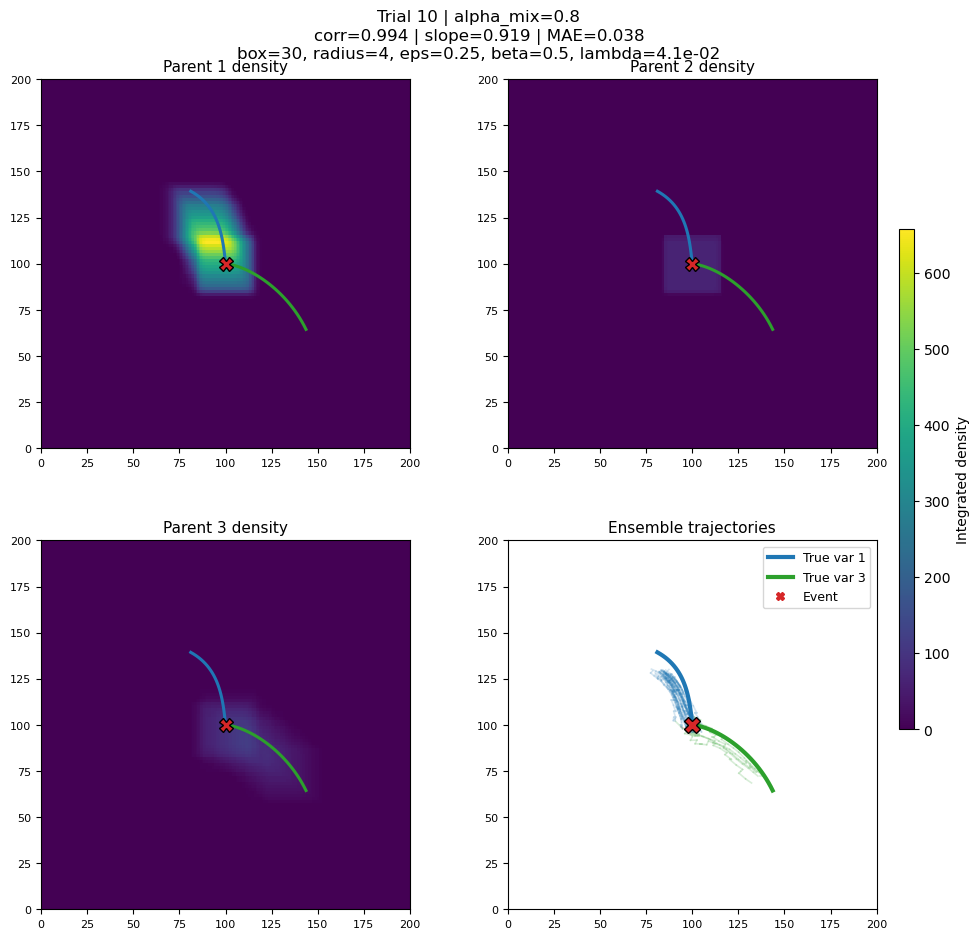

In [252]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def load_bundle_from_paths(npz_path, json_path=None):
    npz_path = Path(npz_path)
    if json_path is None:
        json_path = npz_path.with_suffix(".json")
    else:
        json_path = Path(json_path)

    arrays_npz = np.load(npz_path, allow_pickle=True)
    arrays = {k: arrays_npz[k] for k in arrays_npz.files}

    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    return {"arrays": arrays, "meta": meta}


def _trial_bundle_rows(alphas_df, trial_id):
    dft = alphas_df[alphas_df["trial_id"] == trial_id].copy()
    if len(dft) == 0:
        raise ValueError(f"No rows found in alphas_df for trial_id={trial_id}")
    dft = dft.sort_values("alpha_mix").reset_index(drop=True)
    return dft


def _load_trial_bundles(alphas_df, trial_id):
    dft = _trial_bundle_rows(alphas_df, trial_id)

    bundles = []
    for _, row in dft.iterrows():
        npz_path = row["bundle_npz"]
        json_path = row["bundle_json"] if "bundle_json" in row and pd.notna(row["bundle_json"]) else None
        bundle = load_bundle_from_paths(npz_path, json_path)
        bundles.append((row, bundle))
    return dft, bundles


def _plot_one_bundle_2x2(axs, row, bundle, alpha_members=0.14):
    arrays = bundle["arrays"]
    meta = bundle["meta"]

    xs = np.asarray(arrays["xs"], dtype=float)
    ys = np.asarray(arrays["ys"], dtype=float)
    truth_A = np.asarray(arrays["truth_centers_A"], dtype=float)
    truth_C = np.asarray(arrays["truth_centers_C"], dtype=float)

    density1 = np.asarray(arrays["density_parent1"], dtype=float)
    density2 = np.asarray(arrays["density_parent2"], dtype=float)
    density3 = np.asarray(arrays["density_parent3"], dtype=float)

    centers_all = np.asarray(arrays["centers"], dtype=float)
    parents_all = np.asarray(arrays["parents"], dtype=int)
    lengths = np.asarray(arrays["lengths"], dtype=int)

    event_y, event_x = meta["case_meta"]["event"]
    n_steps_time = int(meta["params"]["n_steps_time"])
    target_len = n_steps_time + 1

    truth_A_cmp = truth_A[-target_len:]
    truth_C_cmp = truth_C[-target_len:]

    ax00, ax01, ax10, ax11 = axs

    vmax = np.nanmax([density1.max(), density2.max(), density3.max()])

    im1 = ax00.pcolormesh(xs, ys, density1, shading="auto", vmin=0, vmax=vmax)
    ax00.plot(truth_A_cmp[:, 1], truth_A_cmp[:, 0], "-", lw=2.0, label="True var. 1")
    ax00.plot(truth_C_cmp[:, 1], truth_C_cmp[:, 0], "-", lw=2.0, label="True var. 3")
    ax00.plot(event_x, event_y, marker="X", markersize=12, markeredgecolor="black", label="Event B")
    ax00.set_title(f"Parent 1 density\nalpha_mix={row['alpha_mix']:.1f}")
    ax00.set_aspect("equal")
    ax00.set_xlabel("x")
    ax00.set_ylabel("y")

    im2 = ax01.pcolormesh(xs, ys, density2, shading="auto", vmin=0, vmax=vmax)
    ax01.plot(truth_A_cmp[:, 1], truth_A_cmp[:, 0], "-", lw=2.0)
    ax01.plot(truth_C_cmp[:, 1], truth_C_cmp[:, 0], "-", lw=2.0)
    ax01.plot(event_x, event_y, marker="X", markersize=12, markeredgecolor="black")
    ax01.set_title("Parent 2 density")
    ax01.set_aspect("equal")
    ax01.set_xlabel("x")
    ax01.set_ylabel("y")

    im3 = ax10.pcolormesh(xs, ys, density3, shading="auto", vmin=0, vmax=vmax)
    ax10.plot(truth_A_cmp[:, 1], truth_A_cmp[:, 0], "-", lw=2.0)
    ax10.plot(truth_C_cmp[:, 1], truth_C_cmp[:, 0], "-", lw=2.0)
    ax10.plot(event_x, event_y, marker="X", markersize=12, markeredgecolor="black")
    ax10.set_title("Parent 3 density")
    ax10.set_aspect("equal")
    ax10.set_xlabel("x")
    ax10.set_ylabel("y")

    var_colors = {1: "tab:blue", 2: "tab:red", 3: "tab:green"}
    shown = set()

    for i in range(len(lengths)):
        L = int(lengths[i])
        if L <= 0:
            continue
        centers = centers_all[i, :L, :]
        parents = parents_all[i, :L]

        for j in range(len(centers) - 1):
            p = int(parents[j])
            label = f"modeled via var. {p}" if p not in shown else None
            ax11.plot(
                centers[j:j+2, 1],
                centers[j:j+2, 0],
                "-",
                color=var_colors.get(p, "k"),
                lw=1.5,
                alpha=alpha_members,
                label=label,
            )
            shown.add(p)

        ax11.plot(centers[0, 1], centers[0, 0], "s", ms=4, color=var_colors.get(int(parents[0]), "k"), alpha=0.9)
        ax11.plot(centers[-1, 1], centers[-1, 0], "*", ms=6, color=var_colors.get(int(parents[-1]), "k"), alpha=0.95)

    ax11.plot(truth_A_cmp[:, 1], truth_A_cmp[:, 0], "-", lw=2.5, color="tab:blue", label="True var. 1")
    ax11.plot(truth_C_cmp[:, 1], truth_C_cmp[:, 0], "-", lw=2.5, color="tab:green", label="True var. 3")
    ax11.plot(event_x, event_y, marker="X", markersize=12, color="tab:red", markeredgecolor="black", label="Event B")
    ax11.set_title("Ensemble trajectories")
    ax11.set_aspect("equal")
    ax11.set_xlabel("x")
    ax11.set_ylabel("y")

    for ax in axs:
        ax.set_xlim(xs.min(), xs.max())
        ax.set_ylim(ys.min(), ys.max())

    return [im1, im2, im3]


def plot_trial_multivariate(
    alphas_df,
    jobs_df,
    trial_id,
    alpha_mix=None,
    alpha_members=0.18,
    figsize=(10, 10),
):
    dft, bundles = _load_trial_bundles(alphas_df, trial_id)

    if alpha_mix is None:
        row, bundle = bundles[0]
    else:
        matches = [(r, b) for (r, b) in bundles if np.isclose(float(r["alpha_mix"]), float(alpha_mix))]
        row, bundle = matches[0]

    job_row = jobs_df[jobs_df["trial_id"] == trial_id].iloc[0]

    arrays = bundle["arrays"]
    meta = bundle["meta"]

    xs = arrays["xs"]
    ys = arrays["ys"]

    density1 = arrays["density_parent1"]
    density2 = arrays["density_parent2"]
    density3 = arrays["density_parent3"]

    truth_A = arrays["truth_centers_A"]
    truth_C = arrays["truth_centers_C"]

    centers_all = arrays["centers"]
    parents_all = arrays["parents"]
    lengths = arrays["lengths"]

    event_y, event_x = meta["case_meta"]["event"]

    vmax = np.nanmax([density1.max(), density2.max(), density3.max()])

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    # --- density panels ---
    titles = ["Parent 1 density", "Parent 2 density", "Parent 3 density"]
    densities = [density1, density2, density3]
    axes_list = [axs[0,0], axs[0,1], axs[1,0]]

    for ax, dens, title in zip(axes_list, densities, titles):
        im = ax.pcolormesh(xs, ys, dens, shading="auto", vmin=0, vmax=vmax)

        ax.plot(truth_A[-30:,1], truth_A[-30:,0], lw=2.2, color="tab:blue")
        ax.plot(truth_C[-30:,1], truth_C[-30:,0], lw=2.2, color="tab:green")

        ax.plot(event_x, event_y, marker="X", ms=10, color="tab:red", markeredgecolor="black")

        ax.set_title(title, fontsize=11)
        ax.set_xlim(xs.min(), xs.max())
        ax.set_ylim(ys.min(), ys.max())
        ax.set_aspect("equal")

        ax.tick_params(labelsize=8)

    # --- trajectories panel ---
    ax = axs[1,1]

    colors = {1: "tab:blue", 2: "tab:red", 3: "tab:green"}

    for i in range(len(lengths)):
        L = lengths[i]
        if L <= 1:
            continue

        centers = centers_all[i, :L]
        parents = parents_all[i, :L]

        for j in range(L-1):
            p = parents[j]
            ax.plot(
                centers[j:j+2,1],
                centers[j:j+2,0],
                color=colors.get(p, "k"),
                lw=1.2,
                alpha=alpha_members,
            )

    # emphasize ground truth

    ax.plot(truth_A[-30:,1], truth_A[-30:,0], lw=3, color="tab:blue")
    ax.plot(truth_C[-30:,1], truth_C[-30:,0], lw=3, color="tab:green")
    ax.plot(event_x, event_y, marker="X", ms=12, color="tab:red", markeredgecolor="black")

    ax.set_title("Ensemble trajectories", fontsize=11)
    ax.set_aspect("equal")
    ax.set_xlim(xs.min(), xs.max())
    ax.set_ylim(ys.min(), ys.max())
    ax.tick_params(labelsize=8)

    # --- colorbar (clean placement) ---
    cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Integrated density", fontsize=10)

    # --- title block ---
    title_text = (
        f"Trial {trial_id} | alpha_mix={row['alpha_mix']:.1f}\n"
        f"corr={job_row['corr_prescribed_vs_estimated_alpha_density']:.3f} | "
        f"slope={job_row['slope_prescribed_vs_estimated_alpha_density']:.3f} | "
        f"MAE={job_row['mean_mae_density']:.3f}\n"
        f"box={job_row['box_size']}, radius={job_row['radius']}, eps={job_row['eps_dbscan']}, "
        f"beta={job_row['beta_softmax']}, lambda={job_row['lambda_a']:.1e}"
    )

    fig.suptitle(title_text, fontsize=12, y=0.97)

    # --- legend (minimal & clean) ---
    legend_elements = [
        Line2D([0], [0], color="tab:blue", lw=3, label="True var 1"),
        Line2D([0], [0], color="tab:green", lw=3, label="True var 3"),
        Line2D([0], [0], marker="X", color="tab:red", lw=0, label="Event"),
    ]

    axs[1,1].legend(handles=legend_elements, loc="upper right", fontsize=9, frameon=True)

    # manual spacing (NO tight_layout)
    plt.subplots_adjust(left=0.06, right=0.9, top=0.9, bottom=0.07, wspace=0.25, hspace=0.25)

    plt.show()


# EXAMPLE USAGE:
plot_trial_multivariate(alphas_df, jobs_df, trial_id=10, alpha_mix=0.8)

# filter runs

In [253]:
# find trials where ALL alpha_mix cases satisfy the tolerance


tol = 0.2
alphas_df["abs_err_density"] = np.abs(
    alphas_df["estimated_alpha_density"] - alphas_df["target_var1"]
)
good_trial_ids = (
    alphas_df.groupby("trial_id")["abs_err_density"]
    .max()  # worst case across alpha grid
    .loc[lambda x: x < tol]
    .index
)

good_trial_ids = list(good_trial_ids)

In [254]:
len(good_trial_ids)

112

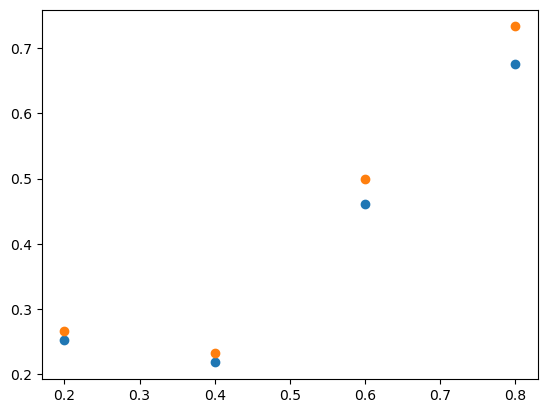

In [255]:
alpha_df_temp = alphas_df[alphas_df['trial_id']==good_trial_ids[0]]
plt.scatter(alpha_df_temp['alpha_mix'],alpha_df_temp['density_frac_var1'])
plt.scatter(alpha_df_temp['alpha_mix'],alpha_df_temp['end_frac_var1'])

In [256]:
good_jobs = jobs_df[jobs_df["trial_id"].isin(good_trial_ids)]

(array([ 2.,  1.,  2.,  4.,  3.,  5., 10., 13., 29., 43.]),
 array([0.79590706, 0.81631447, 0.83672189, 0.85712931, 0.87753673,
        0.89794415, 0.91835156, 0.93875898, 0.9591664 , 0.97957382,
        0.99998124]),
 <BarContainer object of 10 artists>)

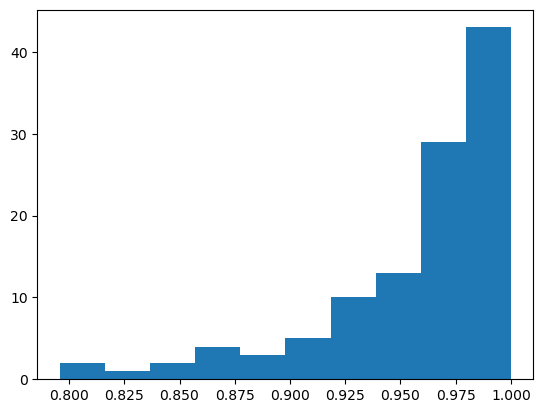

In [257]:
plt.hist(good_jobs['corr_alpha_vs_step_var1'])

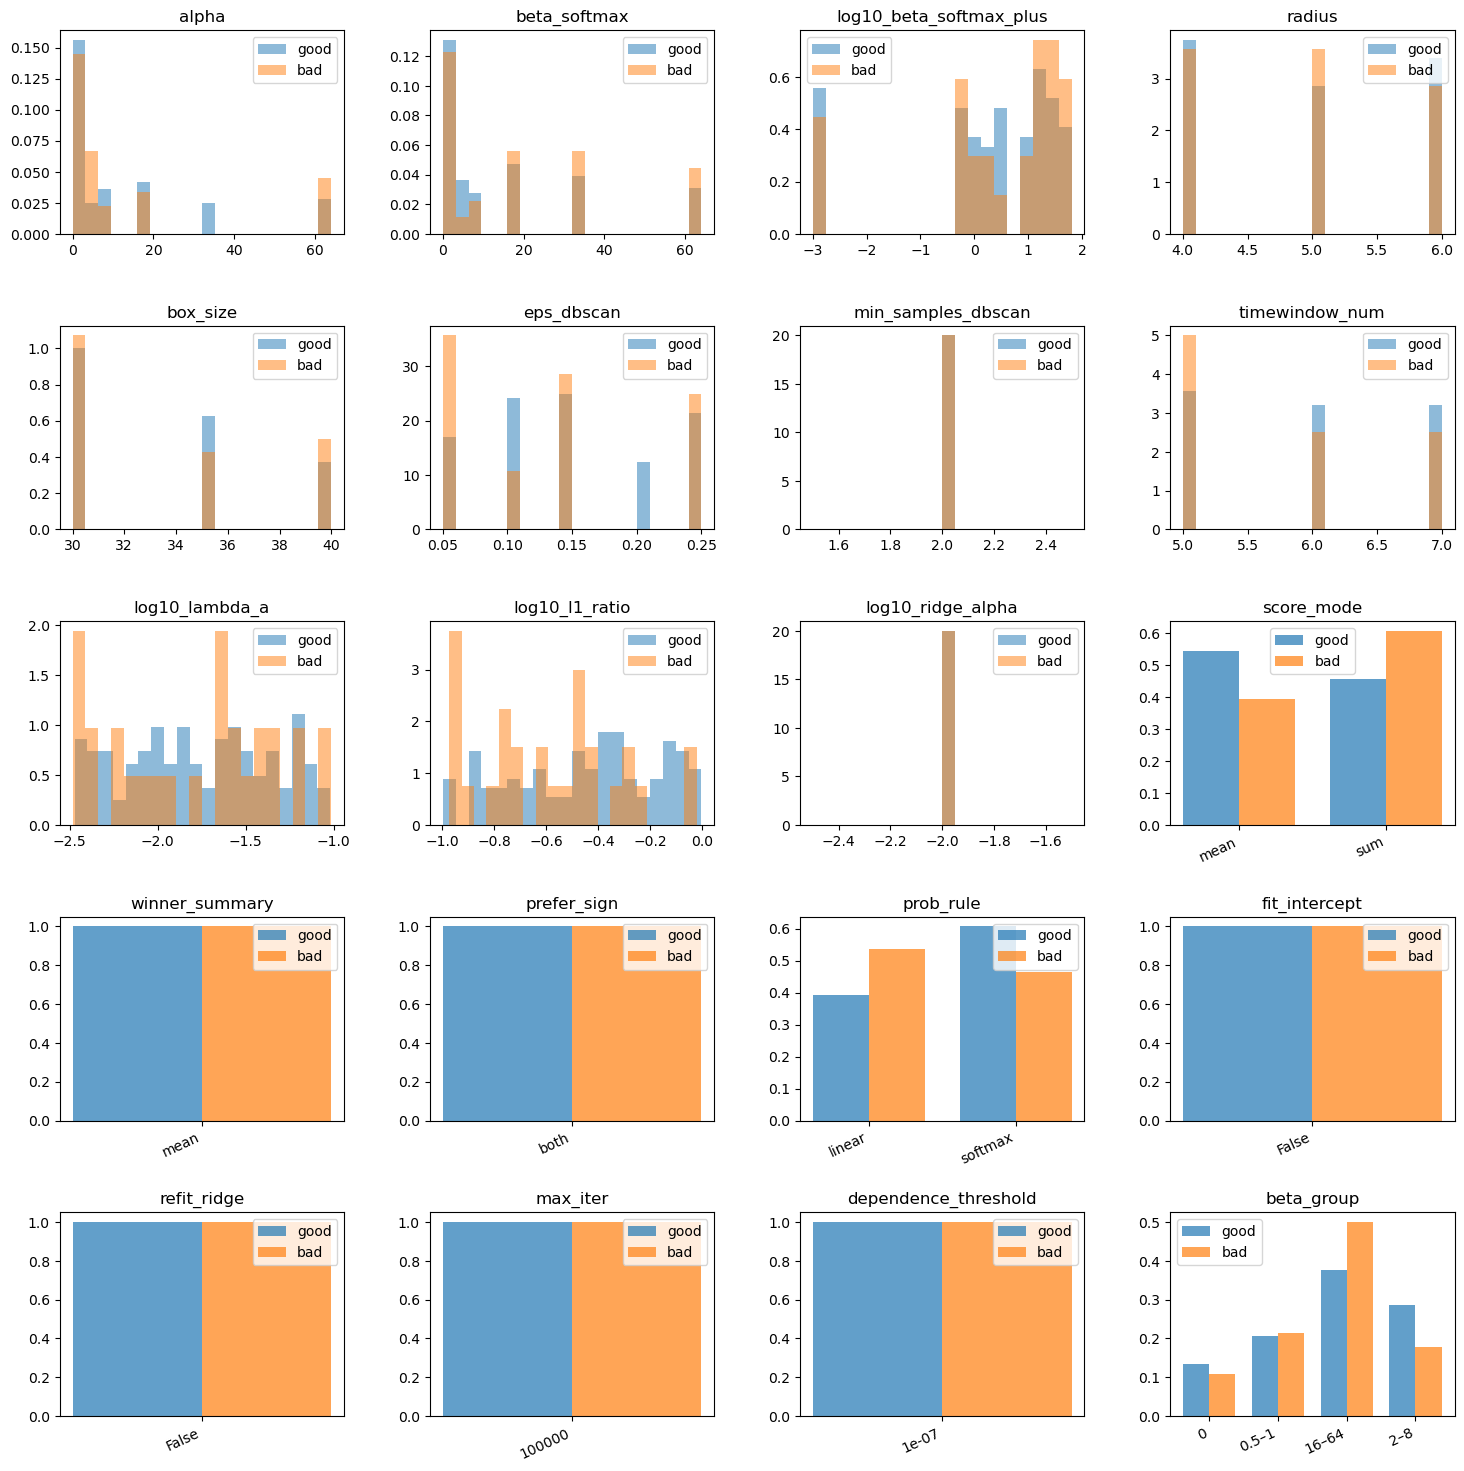

In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define bad jobs as complement
bad_jobs = jobs_df[~jobs_df["trial_id"].isin(good_trial_ids)].copy()

# Copies for transformed plotting columns
good_plot = good_jobs.copy()
bad_plot = bad_jobs.copy()

# Numeric transforms
for df_ in [good_plot, bad_plot]:
    df_["timewindow_num"] = df_["timewindow"].str.replace("d", "", regex=False).astype(float)
    df_["log10_lambda_a"] = np.log10(df_["lambda_a"])
    df_["log10_l1_ratio"] = np.log10(df_["l1_ratio"])
    df_["log10_ridge_alpha"] = np.log10(df_["ridge_alpha"])
    df_["log10_beta_softmax_plus"] = np.log10(df_["beta_softmax"] + 1e-3)

    df_["beta_group"] = df_["beta_softmax"].map({
        0.0: "0",
        0.5: "0.5–1",
        1.0: "0.5–1",
        2.0: "2–8",
        4.0: "2–8",
        8.0: "2–8",
        16.0: "16–64",
        32.0: "16–64",
        64.0: "16–64",
    })

numeric_cols = [
    "alpha",
    "beta_softmax",
    "log10_beta_softmax_plus",
    "radius",
    "box_size",
    "eps_dbscan",
    "min_samples_dbscan",
    "timewindow_num",
    "log10_lambda_a",
    "log10_l1_ratio",
    "log10_ridge_alpha",
]

categorical_cols = [
    "score_mode",
    "winner_summary",
    "prefer_sign",
    "prob_rule",
    "fit_intercept",
    "refit_ridge",
    "max_iter",
    "dependence_threshold",
    "beta_group",
]

n_total = len(numeric_cols) + len(categorical_cols)
ncols = 4
nrows = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).flatten()

# Numeric histograms
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    g = pd.to_numeric(good_plot[col], errors="coerce")
    b = pd.to_numeric(bad_plot[col], errors="coerce")

    g = g[np.isfinite(g)]
    b = b[np.isfinite(b)]

    if len(g) > 0:
        ax.hist(g, bins=20, alpha=0.5, density=True, label="good")
    if len(b) > 0:
        ax.hist(b, bins=20, alpha=0.5, density=True, label="bad")

    ax.set_title(col)
    ax.legend()

# Categorical histograms / bar charts
offset = len(numeric_cols)
for j, col in enumerate(categorical_cols):
    ax = axes[offset + j]

    g_counts = good_plot[col].value_counts(normalize=True).sort_index()
    b_counts = bad_plot[col].value_counts(normalize=True).sort_index()

    cats = sorted(set(g_counts.index).union(set(b_counts.index)), key=lambda x: str(x))
    x = np.arange(len(cats))
    width = 0.38

    ax.bar(x - width/2, [g_counts.get(c, 0.0) for c in cats], width=width, label="good", alpha=0.7)
    ax.bar(x + width/2, [b_counts.get(c, 0.0) for c in cats], width=width, label="bad", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats], rotation=25, ha="right")
    ax.set_title(col)
    ax.legend()

# Turn off unused axes
for ax in axes[n_total:]:
    ax.axis("off")

plt.subplots_adjust(wspace=0.3, hspace=0.45)
plt.show()

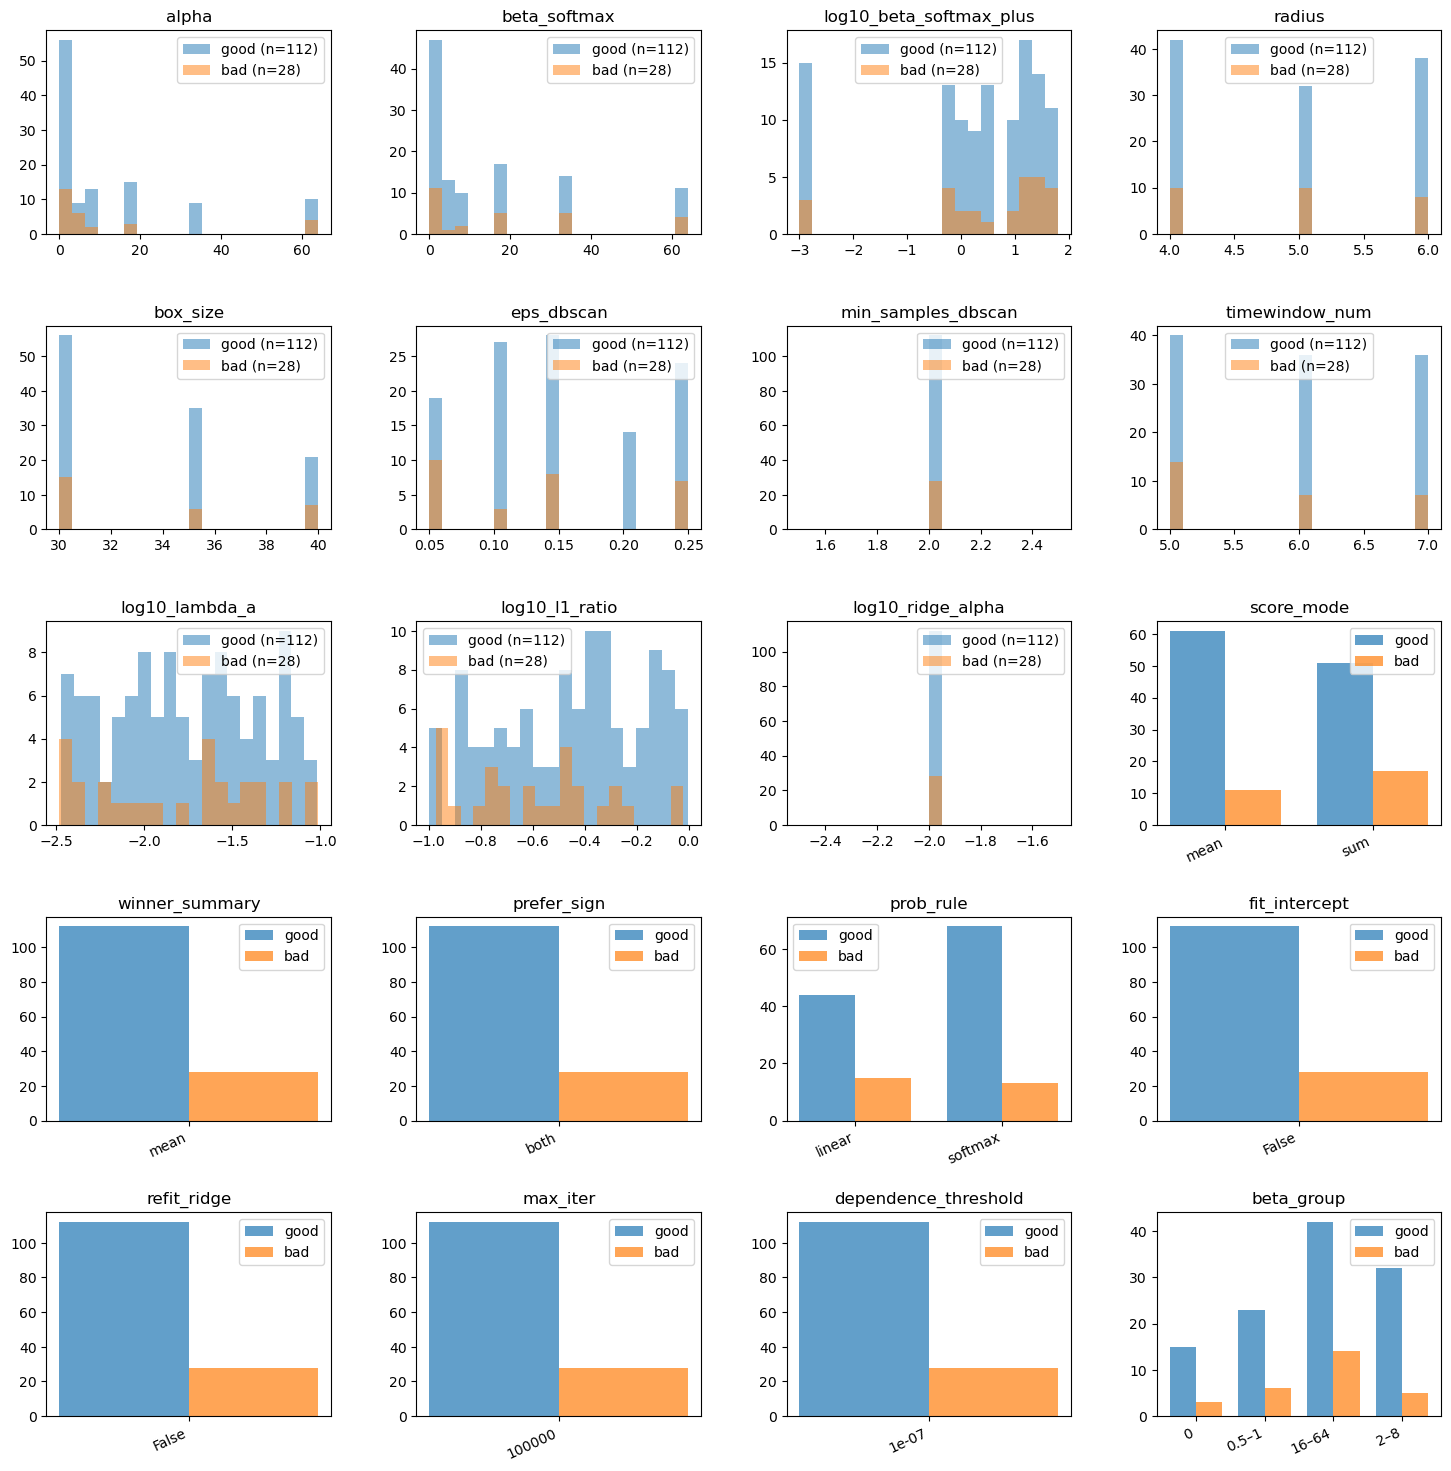

In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define bad jobs as complement
bad_jobs = jobs_df[~jobs_df["trial_id"].isin(good_trial_ids)].copy()

# Copies for transformed plotting columns
good_plot = good_jobs.copy()
bad_plot = bad_jobs.copy()

# Numeric transforms
for df_ in [good_plot, bad_plot]:
    df_["timewindow_num"] = df_["timewindow"].str.replace("d", "", regex=False).astype(float)
    df_["log10_lambda_a"] = np.log10(df_["lambda_a"])
    df_["log10_l1_ratio"] = np.log10(df_["l1_ratio"])
    df_["log10_ridge_alpha"] = np.log10(df_["ridge_alpha"])
    df_["log10_beta_softmax_plus"] = np.log10(df_["beta_softmax"] + 1e-3)

    df_["beta_group"] = df_["beta_softmax"].map({
        0.0: "0",
        0.5: "0.5–1",
        1.0: "0.5–1",
        2.0: "2–8",
        4.0: "2–8",
        8.0: "2–8",
        16.0: "16–64",
        32.0: "16–64",
        64.0: "16–64",
    })

numeric_cols = [
    "alpha",
    "beta_softmax",
    "log10_beta_softmax_plus",
    "radius",
    "box_size",
    "eps_dbscan",
    "min_samples_dbscan",
    "timewindow_num",
    "log10_lambda_a",
    "log10_l1_ratio",
    "log10_ridge_alpha",
]

categorical_cols = [
    "score_mode",
    "winner_summary",
    "prefer_sign",
    "prob_rule",
    "fit_intercept",
    "refit_ridge",
    "max_iter",
    "dependence_threshold",
    "beta_group",
]

n_total = len(numeric_cols) + len(categorical_cols)
ncols = 4
nrows = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).flatten()

# --------------------------
# Numeric histograms (COUNTS)
# --------------------------
for i, col in enumerate(numeric_cols):
    ax = axes[i]

    g = pd.to_numeric(good_plot[col], errors="coerce")
    b = pd.to_numeric(bad_plot[col], errors="coerce")

    g = g[np.isfinite(g)]
    b = b[np.isfinite(b)]

    if len(g) > 0:
        ax.hist(g, bins=20, alpha=0.5, label=f"good (n={len(g)})")
    if len(b) > 0:
        ax.hist(b, bins=20, alpha=0.5, label=f"bad (n={len(b)})")

    ax.set_title(col)
    ax.legend()

# --------------------------------
# Categorical (RAW COUNTS, not frac)
# --------------------------------
offset = len(numeric_cols)
for j, col in enumerate(categorical_cols):
    ax = axes[offset + j]

    g_counts = good_plot[col].value_counts().sort_index()
    b_counts = bad_plot[col].value_counts().sort_index()

    cats = sorted(set(g_counts.index).union(set(b_counts.index)), key=lambda x: str(x))
    x = np.arange(len(cats))
    width = 0.38

    ax.bar(x - width/2, [g_counts.get(c, 0) for c in cats],
           width=width, label="good", alpha=0.7)
    ax.bar(x + width/2, [b_counts.get(c, 0) for c in cats],
           width=width, label="bad", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cats], rotation=25, ha="right")
    ax.set_title(col)
    ax.legend()

# Turn off unused axes
for ax in axes[n_total:]:
    ax.axis("off")

plt.subplots_adjust(wspace=0.3, hspace=0.45)
plt.show()

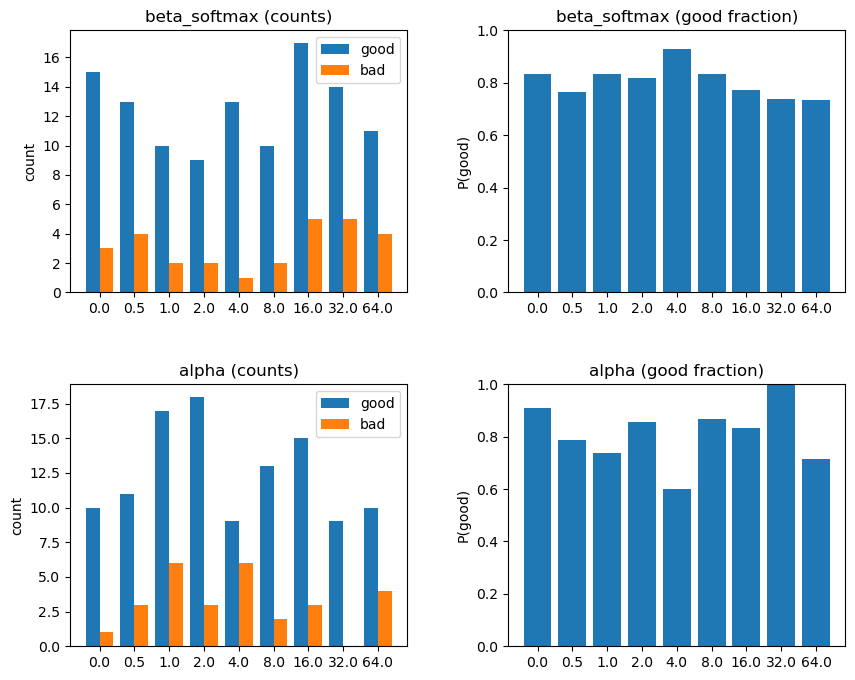

In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define bad jobs
bad_jobs = jobs_df[~jobs_df["trial_id"].isin(good_trial_ids)].copy()

# Ensure numeric
good_beta = pd.to_numeric(good_jobs["beta_softmax"], errors="coerce")
bad_beta  = pd.to_numeric(bad_jobs["beta_softmax"], errors="coerce")

good_alpha = pd.to_numeric(good_jobs["alpha"], errors="coerce")
bad_alpha  = pd.to_numeric(bad_jobs["alpha"], errors="coerce")

# Unique sorted values
beta_vals = sorted(jobs_df["beta_softmax"].dropna().unique())
alpha_vals = sorted(jobs_df["alpha"].dropna().unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# ----------------------
# (1) beta_softmax counts
# ----------------------
ax = axes[0, 0]
g_counts = [(good_beta == v).sum() for v in beta_vals]
b_counts = [(bad_beta == v).sum() for v in beta_vals]

x = np.arange(len(beta_vals))
width = 0.4

ax.bar(x - width/2, g_counts, width, label="good")
ax.bar(x + width/2, b_counts, width, label="bad")

ax.set_xticks(x)
ax.set_xticklabels(beta_vals)
ax.set_title("beta_softmax (counts)")
ax.set_ylabel("count")
ax.legend()

# ----------------------------
# (2) beta_softmax success rate
# ----------------------------
ax = axes[0, 1]
total_counts = [(jobs_df["beta_softmax"] == v).sum() for v in beta_vals]
good_counts = [(good_beta == v).sum() for v in beta_vals]

success_rate = [
    g / t if t > 0 else np.nan
    for g, t in zip(good_counts, total_counts)
]

ax.bar(x, success_rate)
ax.set_xticks(x)
ax.set_xticklabels(beta_vals)
ax.set_ylim(0, 1)
ax.set_title("beta_softmax (good fraction)")
ax.set_ylabel("P(good)")

# ----------------------
# (3) alpha counts
# ----------------------
ax = axes[1, 0]
g_counts = [(good_alpha == v).sum() for v in alpha_vals]
b_counts = [(bad_alpha == v).sum() for v in alpha_vals]

x = np.arange(len(alpha_vals))

ax.bar(x - width/2, g_counts, width, label="good")
ax.bar(x + width/2, b_counts, width, label="bad")

ax.set_xticks(x)
ax.set_xticklabels(alpha_vals)
ax.set_title("alpha (counts)")
ax.set_ylabel("count")
ax.legend()

# ----------------------------
# (4) alpha success rate
# ----------------------------
ax = axes[1, 1]
total_counts = [(jobs_df["alpha"] == v).sum() for v in alpha_vals]
good_counts = [(good_alpha == v).sum() for v in alpha_vals]

success_rate = [
    g / t if t > 0 else np.nan
    for g, t in zip(good_counts, total_counts)
]

ax.bar(x, success_rate)
ax.set_xticks(x)
ax.set_xticklabels(alpha_vals)
ax.set_ylim(0, 1)
ax.set_title("alpha (good fraction)")
ax.set_ylabel("P(good)")

plt.subplots_adjust(wspace=0.3, hspace=0.35)
plt.show()

# understand the relationship of performance with physical validity factors

In [261]:
good_jobs.keys()

Index(['trial_id', 'timewindow', 'box_size', 'radius', 'eps_dbscan',
       'min_samples_dbscan', 'score_mode', 'winner_summary', 'alpha',
       'prefer_sign', 'prob_rule', 'beta_softmax', 'lambda_a', 'l1_ratio',
       'dependence_threshold', 'max_iter', 'fit_intercept', 'refit_ridge',
       'ridge_alpha', 'n_alpha', 'n_alpha_valid_physical',
       'frac_alpha_valid_physical', 'mean_mae_initial', 'mean_mae_end',
       'mean_mae_step', 'mean_mae_density', 'max_mae_initial', 'max_mae_end',
       'max_mae_step', 'max_mae_density', 'mean_ok_frac', 'min_ok_frac',
       'mean_mean_n_steps', 'min_q25_n_steps', 'mean_mean_net_displacement',
       'mean_mean_path_length', 'mean_mean_stagnant_frac',
       'mean_density_var2_frac', 'mean_step_var2_frac',
       'mean_initial_var2_frac', 'mean_end_var2_frac',
       'corr_alpha_vs_density_var1', 'corr_alpha_vs_step_var1',
       'corr_alpha_vs_end_var1', 'corr_alpha_vs_initial_var1',
       'corr_prescribed_vs_estimated_alpha_end',
      

/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/2255831276.py:51: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(g, ax=ax, fill=True, alpha=0.35, label=f"good (n={len(g)})")
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/2255831276.py:53: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(b, ax=ax, fill=True, alpha=0.35, label=f"bad (n={len(b)})")
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/2255831276.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/glade/derecho/scratch/jhayron/tmp/ipykernel_55350/2255831276.py:51: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(g, ax=ax, fill=True

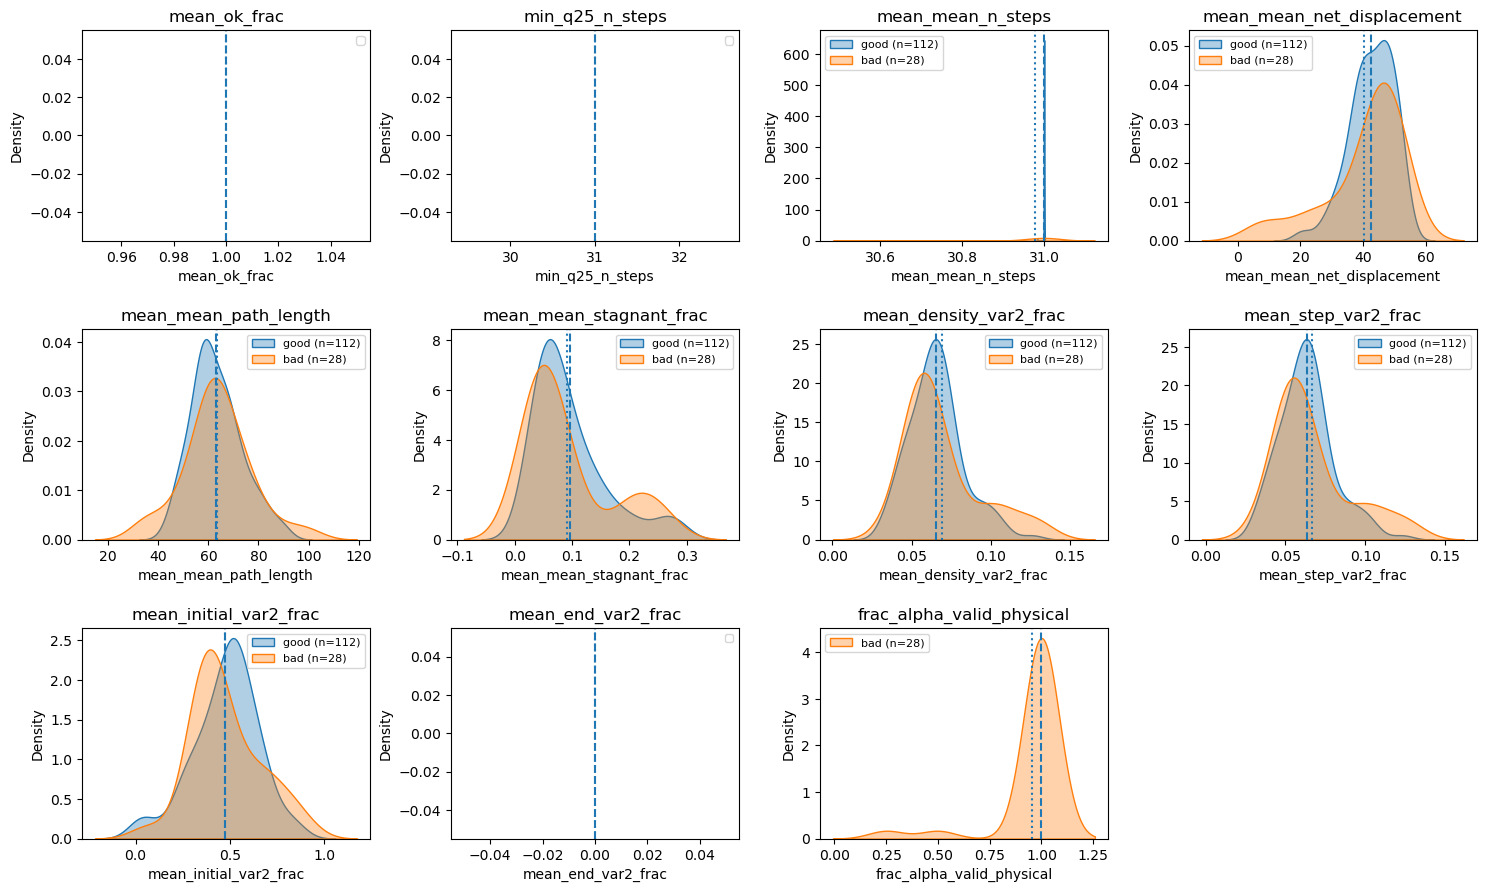

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# bad = complement of good
bad_jobs = jobs_df[~jobs_df["trial_id"].isin(good_jobs["trial_id"])].copy()

phys_cols = [
    "ok_frac",
    "mean_ok_frac",
    "q25_n_steps",
    "min_q25_n_steps",
    "mean_mean_n_steps",
    "mean_net_displacement",
    "mean_mean_net_displacement",
    "mean_path_length",
    "mean_mean_path_length",
    "mean_stagnant_frac",
    "mean_mean_stagnant_frac",
    "frac_members_any_nontrivial",
    "frac_members_end_nontrivial",
    "frac_members_use_parent1",
    "frac_members_use_parent3",
    "frac_members_use_both_nontrivial",
    "mean_unique_nontrivial_count",
    "mean_density_var2_frac",
    "mean_step_var2_frac",
    "mean_initial_var2_frac",
    "mean_end_var2_frac",
    "frac_alpha_valid_physical",
]

# keep only columns that actually exist
phys_cols = [c for c in phys_cols if c in jobs_df.columns]

ncols = 4
nrows = int(np.ceil(len(phys_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, phys_cols):
    g = pd.to_numeric(good_jobs[col], errors="coerce")
    b = pd.to_numeric(bad_jobs[col], errors="coerce")

    g = g[np.isfinite(g)]
    b = b[np.isfinite(b)]

    if len(g) > 1:
        sns.kdeplot(g, ax=ax, fill=True, alpha=0.35, label=f"good (n={len(g)})")
    if len(b) > 1:
        sns.kdeplot(b, ax=ax, fill=True, alpha=0.35, label=f"bad (n={len(b)})")

    # means
    if len(g) > 0:
        ax.axvline(g.mean(), linestyle="--", linewidth=1.5)
    if len(b) > 0:
        ax.axvline(b.mean(), linestyle=":", linewidth=1.5)

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axes[len(phys_cols):]:
    ax.axis("off")

plt.subplots_adjust(wspace=0.28, hspace=0.42)
plt.show()

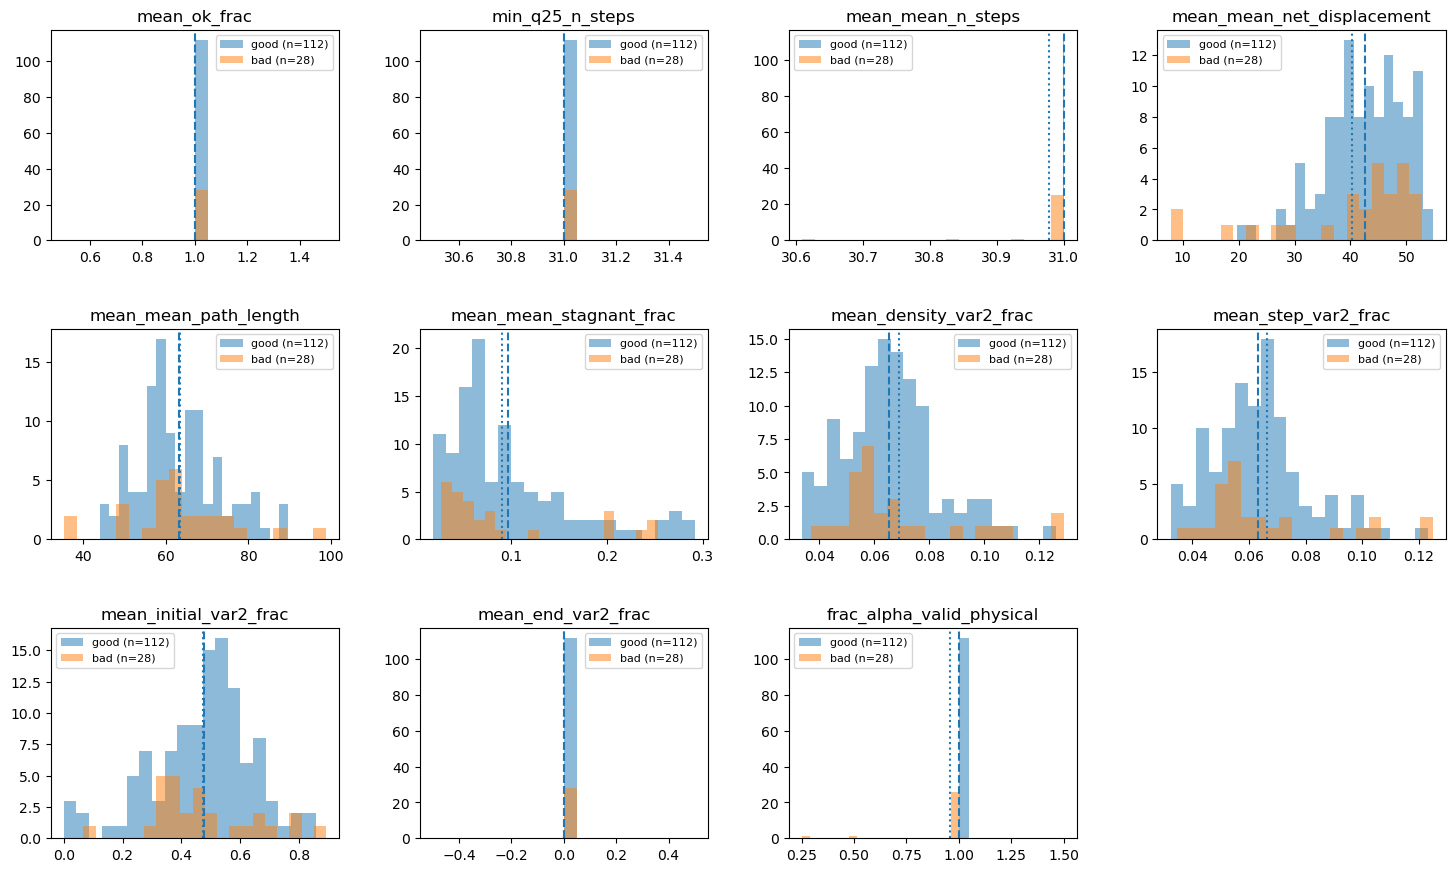

In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# bad = complement of good
bad_jobs = jobs_df[~jobs_df["trial_id"].isin(good_jobs["trial_id"])].copy()

phys_cols = [
    "ok_frac",
    "mean_ok_frac",
    "q25_n_steps",
    "min_q25_n_steps",
    "mean_mean_n_steps",
    "mean_net_displacement",
    "mean_mean_net_displacement",
    "mean_path_length",
    "mean_mean_path_length",
    "mean_stagnant_frac",
    "mean_mean_stagnant_frac",
    "frac_members_any_nontrivial",
    "frac_members_end_nontrivial",
    "frac_members_use_parent1",
    "frac_members_use_parent3",
    "frac_members_use_both_nontrivial",
    "mean_unique_nontrivial_count",
    "mean_density_var2_frac",
    "mean_step_var2_frac",
    "mean_initial_var2_frac",
    "mean_end_var2_frac",
    "frac_alpha_valid_physical",
]

# keep only existing columns
phys_cols = [c for c in phys_cols if c in jobs_df.columns]

ncols = 4
nrows = int(np.ceil(len(phys_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, phys_cols):
    g = pd.to_numeric(good_jobs[col], errors="coerce")
    b = pd.to_numeric(bad_jobs[col], errors="coerce")

    g = g[np.isfinite(g)]
    b = b[np.isfinite(b)]

    if len(g) > 0:
        ax.hist(g, bins=20, alpha=0.5, label=f"good (n={len(g)})")
    if len(b) > 0:
        ax.hist(b, bins=20, alpha=0.5, label=f"bad (n={len(b)})")

    # mean lines
    if len(g) > 0:
        ax.axvline(g.mean(), linestyle="--", linewidth=1.5)
    if len(b) > 0:
        ax.axvline(b.mean(), linestyle=":", linewidth=1.5)

    ax.set_title(col)
    ax.legend(fontsize=8)

# turn off unused axes
for ax in axes[len(phys_cols):]:
    ax.axis("off")

plt.subplots_adjust(wspace=0.28, hspace=0.42)
plt.show()

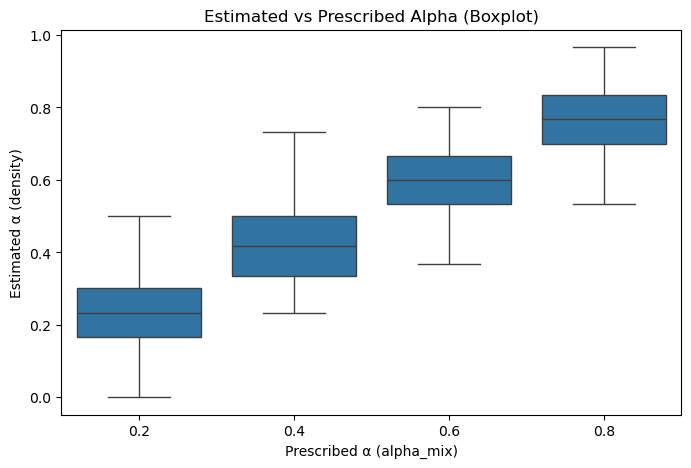

In [265]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# df_plot = alphas_df[alphas_df["trial_id"].isin(good_trial_ids)].copy()
df_plot = alphas_df

# ensure numeric
df_plot["alpha_mix"] = pd.to_numeric(df_plot["alpha_mix"], errors="coerce")
df_plot["estimated_alpha"] = pd.to_numeric(df_plot["estimated_alpha_end"], errors="coerce")

# drop invalid
df_plot = df_plot.dropna(subset=["alpha_mix", "estimated_alpha"])

# sort alphas
order = sorted(df_plot["alpha_mix"].unique())

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df_plot,
    x="alpha_mix",
    y="estimated_alpha",
    order=order,
    showfliers=False,  # cleaner
    ax=ax
)

# ideal line
# ax.plot(order, order, linestyle="--")

ax.set_xlabel("Prescribed α (alpha_mix)")
ax.set_ylabel("Estimated α (density)")
ax.set_title("Estimated vs Prescribed Alpha (Boxplot)")

plt.show()